In [1]:
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL
import polars as pl

In [2]:
_root = Path.cwd()
while not (_root / "src").exists():
    _root = _root.parent
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

from src import config as src_config, data_utils, plots, strategy_utils

STACKSATS_DATA_PATH = src_config.STACKSATS_DATA_PATH
RAW_PATH = src_config.RAW_PATH

data_utils.check_stacksats_data(STACKSATS_DATA_PATH, RAW_PATH)

RAW_DIR = src_config.DATA_DIR / "raw"
TRAIN_PATH = src_config.TRAIN_PATH
TEST_PATH = src_config.TEST_PATH

In [3]:
candidate_cols = [

    "active_price",

    "realized_price",

    "mvrv",

    "mvrv_zscore",

    "market_cap",

    "supply_btc"


]

In [4]:
import polars as pl
df = (
    pl.scan_parquet(TRAIN_PATH)
    .filter(
        (pl.col("day_utc") >= pl.date(2018, 1, 1))
        )
    .filter(pl.col("metric").is_in(candidate_cols))
    .select(["day_utc", "metric", "value"])
    .collect()
    .pivot(
        on="metric",
        index="day_utc",
        values="value",
        aggregate_function="first",
    )
    .with_columns(
        (pl.col("market_cap") / pl.col("supply_btc")).alias("price_usd")
    )
    .rename({"day_utc": "date"})
    .filter(
        pl.col("price_usd").is_finite()
        & (pl.col("price_usd") > 0)
    )
    .sort("date")
)

### ExampleMVRVStrategy

It is an experimental, score-focused Bitcoin DCA allocation strategy that extends a basic MVRV-based strategy by integrating multiple advanced features and combining them with the StackSats MVRV/MA signal model.
The strategy requires a set of "core" engineered features (like price_vs_ma, mvrv_zscore, etc.) plus a substantial number of BRK features:
Netflow (fast/slow/slope), activity, liquidity, exchange share, miner pressure, ROI, hash momentum, etc.


Base preference is calculated from the standard StackSats MVRV/MA approach (using rolling statistical/price features, like mvrv_zscore and price_vs_ma)
The strategy computes additional components from the BRK features like netflow (fast/slow/slope), activity level, etc with hardcoded weights 

Dynamic temperature and gating mechanisms:
The overall aggressiveness of the allocation (“temperature”) is dynamically adjusted for model confidence, volatility, and where the MVRV regime sits (e.g., value zone or dangerous zone).
Gating mechanisms alter how much overlay components contribute depending on the market state (e.g., possibly more cautious in dangerous/overheated zones)

Combining the Model Output:
The final preference (score) is a weighted sum of:
The baseline MVRV/MA-driven preference scaled by the dynamic temperature.
The overlay composite, scaled and shrunk by uncertainty (i.e., lower weight in high-volatility periods), and incorporating model confidence.

This "preference" is NOT the actual allocation/weight, but a signal the allocation engine will use to derive allocation weights.

It returns a TargetProfile with the date and “value” columns (the value being the daily calculated preference score).

Summary:
It produces a dynamically weighted signal for each date, mixing baseline MVRV regime scores and a rich set of overlay “on-chain” features, factoring in both market confidence and market regime to provide a daily intent score for StackSats to consume and convert into allocation weights.

This strategy is ideal for experimenting with new on-chain data sources or regime interaction terms.
The output is a date-indexed “preference” timeseries, not a direct portfolio allocation, but the StackSats kernel will convert it into weights for you.

In [5]:
from stacksats.strategies.experimental.overlays import ExampleMVRVStrategy
from stacksats import StrategyRunner, ComparisonConfig, UniformStrategy, MVRVStrategy
from datetime import date
from stacksats import ExportConfig

In [6]:
example_strategy = ExampleMVRVStrategy()
runner = StrategyRunner()

In [7]:
start_date = df.select(pl.col("date").min()).item()
end_date = df.select(pl.col("date").max()).item()

config = ExportConfig(
    range_start=str(start_date)[:10],
    range_end=str(end_date)[:10],
    output_dir="./output",
    btc_price_col="price_usd"
)

uniform_export = runner.export(UniformStrategy(), config, btc_df=df)
strategy_export = runner.export(example_strategy, config, btc_df=df)

In [8]:
uniform_df = uniform_export.to_dataframe()
strategy_df = strategy_export.to_dataframe()

uniform_df.head()

start_date,end_date,day_index,date,price_usd,weight
datetime[μs],datetime[μs],f64,datetime[μs],f64,f64
2018-01-01 00:00:00,2018-12-31 00:00:00,0.0,2018-01-01 00:00:00,13466.31,0.00274
2018-01-01 00:00:00,2018-12-31 00:00:00,1.0,2018-01-02 00:00:00,14888.11,0.00274
2018-01-01 00:00:00,2018-12-31 00:00:00,2.0,2018-01-03 00:00:00,15098.14,0.00274
2018-01-01 00:00:00,2018-12-31 00:00:00,3.0,2018-01-04 00:00:00,15144.99,0.00274
2018-01-01 00:00:00,2018-12-31 00:00:00,4.0,2018-01-05 00:00:00,16960.01,0.00274


In [9]:
strategy_df.head()

start_date,end_date,day_index,date,price_usd,weight
datetime[μs],datetime[μs],f64,datetime[μs],f64,f64
2018-01-01 00:00:00,2018-12-31 00:00:00,0.0,2018-01-01 00:00:00,13466.31,0.00274
2018-01-01 00:00:00,2018-12-31 00:00:00,1.0,2018-01-02 00:00:00,14888.11,0.00274
2018-01-01 00:00:00,2018-12-31 00:00:00,2.0,2018-01-03 00:00:00,15098.14,0.00274
2018-01-01 00:00:00,2018-12-31 00:00:00,3.0,2018-01-04 00:00:00,15144.99,0.00274
2018-01-01 00:00:00,2018-12-31 00:00:00,4.0,2018-01-05 00:00:00,16960.01,0.00274


In [10]:
mvrv_export = runner.export(MVRVStrategy(), config, btc_df=df)
mvrv_df = mvrv_export.to_dataframe()

mvrv_df.head()

start_date,end_date,day_index,date,price_usd,weight
datetime[μs],datetime[μs],f64,datetime[μs],f64,f64
2018-01-01 00:00:00,2018-12-31 00:00:00,0.0,2018-01-01 00:00:00,13466.31,0.00274
2018-01-01 00:00:00,2018-12-31 00:00:00,1.0,2018-01-02 00:00:00,14888.11,0.00274
2018-01-01 00:00:00,2018-12-31 00:00:00,2.0,2018-01-03 00:00:00,15098.14,0.00274
2018-01-01 00:00:00,2018-12-31 00:00:00,3.0,2018-01-04 00:00:00,15144.99,0.00274
2018-01-01 00:00:00,2018-12-31 00:00:00,4.0,2018-01-05 00:00:00,16960.01,0.00274


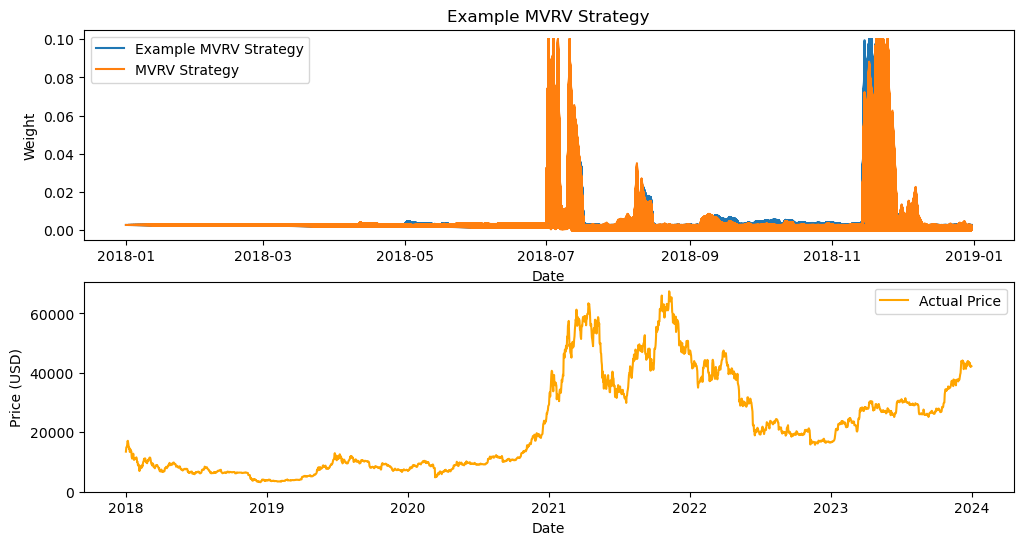

In [11]:
mvrv_plot_df = (
    mvrv_df.filter(pl.col("date") <= pl.date(2018, 12, 31))
    .select(["date", "weight"])
)
strategy_plot_df = (
    strategy_df.filter(pl.col("date") <= pl.date(2018, 12, 31))
    .select(["date", "weight"])
)

fig, ax = plt.subplots(2,1,figsize=(12, 6))
axs = ax.flatten()
axs[0].plot(strategy_plot_df["date"], strategy_plot_df["weight"], label="Example MVRV Strategy")
axs[0].plot(mvrv_plot_df["date"], mvrv_plot_df["weight"], label="MVRV Strategy") 
axs[0].set_xlabel("Date")
axs[0].set_ylabel("Weight")
axs[0].set_title("Example MVRV Strategy")
axs[0].legend()

axs[1].plot(df["date"], df["price_usd"], label="Actual Price", color="orange")
axs[1].set_xlabel("Date")
axs[1].set_ylabel("Price (USD)")
plt.legend()
plt.show()

In [12]:
from stacksats import BacktestConfig

example_bt = runner.backtest(
    example_strategy,
    config=BacktestConfig(
        start_date=str(start_date),
        end_date=str(end_date),
        output_dir="output",
    ),
    btc_df=df,
)

In [13]:
example_bt.to_dataframe()

window,min_sats_per_dollar,max_sats_per_dollar,uniform_sats_per_dollar,dynamic_sats_per_dollar,uniform_percentile,dynamic_percentile,excess_percentile
str,f64,f64,f64,f64,f64,f64,f64
"""2018-01-01 → 2018-12-31""",5842.827929,31422.726801,14736.064632,13485.080263,34.766505,29.876007,-4.890498
"""2018-01-02 → 2019-01-01""",5842.827929,31422.726801,14787.64918,13500.285071,34.968165,29.935447,-5.032718
"""2018-01-03 → 2019-01-02""",5842.827929,31422.726801,14839.550357,13517.096374,35.171063,30.001168,-5.169895
"""2018-01-04 → 2019-01-03""",5842.827929,31422.726801,14893.784195,13533.895337,35.383081,30.066841,-5.31624
"""2018-01-05 → 2019-01-04""",5842.827929,31422.726801,14947.312798,13550.888349,35.592341,30.133272,-5.459069
…,…,…,…,…,…,…,…
"""2022-12-28 → 2023-12-27""",2263.929335,6055.677106,3645.624389,2412.72051,36.43953,3.924079,-32.515451
"""2022-12-29 → 2023-12-28""",2263.929335,6055.677106,3635.497492,2404.949974,36.172452,3.719146,-32.453306
"""2022-12-30 → 2023-12-29""",2263.929335,6055.677106,3625.550662,2406.059884,35.910124,3.748418,-32.161706


In [14]:
strategies_train = {
    "dynamic": ExampleMVRVStrategy(),
    "baseline": UniformStrategy(),
}

train_years  = range(src_config.TRAIN_START_YEAR, src_config.SPLIT_YEAR)   # 2018–2023
merged_train = strategy_utils.run_year_by_year(strategies_train, df, train_years, runner)

perf_vf   = strategy_utils.compute_performance_summary(merged_train, "dynamic", "baseline")

print(f"[Train] Example MVRV SPD : {perf_vf['sats_per_dollar_dynamic']:.2f}")
print(f"[Train] Baseline SPD    : {perf_vf['sats_per_dollar_baseline']:.2f}")
print(f"Example MVRV {abs(perf_vf['pct_diff_vs_baseline']):.2f}% {perf_vf['performance_label']} than Uniform")

2018: exported 365 rows
2018: exported 365 rows
2019: exported 365 rows


2019: exported 365 rows


2020: exported 365 rows
2020: exported 365 rows


2021: exported 365 rows
2021: exported 365 rows


2022: exported 365 rows
2022: exported 365 rows


2023: exported 365 rows
2023: exported 365 rows
[Train] Example MVRV SPD : 8109.52
[Train] Baseline SPD    : 8418.79
Example MVRV 3.67% worse than Uniform


## Adding Test data

In [15]:
df_test = (
    pl.scan_parquet(TEST_PATH)
    .filter(
        (pl.col("day_utc") >= pl.date(2024, 1, 1)) #Test data should anyways start from Jan 1, 2024
        )
    .filter(pl.col("metric").is_in(candidate_cols))
    .select(["day_utc", "metric", "value"])
    .collect()
    .pivot(
        on="metric",
        index="day_utc",
        values="value",
        aggregate_function="first",
    )
    .with_columns(
        (pl.col("market_cap") / pl.col("supply_btc")).alias("price_usd")
    )
    .rename({"day_utc": "date"})
    .filter(
        pl.col("price_usd").is_finite()
        & (pl.col("price_usd") > 0)
    )
    .sort("date")
)

In [16]:
strategies_test = {
    "dynamic": ExampleMVRVStrategy(),
    "baseline": UniformStrategy(),
}

test_years  = range(src_config.SPLIT_YEAR, src_config.TEST_END_YEAR + 1)   # 2024–2025
merged_test = strategy_utils.run_year_by_year(strategies_test, df_test, test_years, runner)

perf_test_vf   = strategy_utils.compute_performance_summary(merged_test, "dynamic", "baseline")

2024: exported 365 rows
2024: exported 365 rows


2025: exported 365 rows
2025: exported 365 rows


In [17]:
combined_plot_df = (
    pd.concat([merged_train.to_pandas(), merged_test.to_pandas()])
    .sort_values("date")
    .reset_index(drop=True)
)

cols = plots.StrategyColumns(
    weight="dynamic_weight",
    spd="sats_per_dollar_dynamic",
    sats_accum="sats_accum_dynamic",
)

# Full period
full_plot = plots.plot_strategy_full_period(
    combined_plot_df, 
    cols, 
    "Example-MVRV Strategy", 
    date_range=("2018-01-01", str(combined_plot_df["date"].max().date())),
    test_start_date="2024-01-01"
)
plt.show()

## MVRVPlusStrategy

Essentially the same as ExampleMVRV.

It starts by generating preference scores using the standard StackSats MVRV model. It adds two derived features: 21-day rolling volatility (plus_vol21) and 90-day rolling drawdown (plus_drawdown90), capturing recent risk and price stress. It requires several "overlay" features provided by the framework, such as netflow, exchange share, activity divergence, ROI context, liquidity impulse, miner pressure, and hash momentum.

The strategy dynamically scales the baseline preference up or down depending on the "zone" (deep value, overheated, neutral) using parameters like deep_value_boost, overheat_dampen, and neutral_scale.
It reduces allocation in the presence of:
- High realized or expected volatility.
- Large price drawdowns.
- Strong disagreement between value and trend signals.
- Lack of model confidence in favorable conditions.
- Additional small penalty for very high realized volatility.
The overlays (netflow, activity, ROI, etc.) are linearly combined into an “overlay” term using fixed weights, with risk and value zone gating applied to each

In [18]:
from stacksats.strategies.experimental.overlays import MVRVPlusStrategy

In [19]:
mvrv_plus = MVRVPlusStrategy()

In [20]:
example_bt = runner.backtest(
    mvrv_plus,
    config=BacktestConfig(
        start_date=str(start_date),
        end_date=str(end_date),
        output_dir="output",
    ),
    btc_df=df,
)
example_bt.to_dataframe()

window,min_sats_per_dollar,max_sats_per_dollar,uniform_sats_per_dollar,dynamic_sats_per_dollar,uniform_percentile,dynamic_percentile,excess_percentile
str,f64,f64,f64,f64,f64,f64,f64
"""2018-01-01 → 2018-12-31""",5842.827929,31422.726801,14736.064632,13107.300385,34.766505,28.399145,-6.36736
"""2018-01-02 → 2019-01-01""",5842.827929,31422.726801,14787.64918,13132.085134,34.968165,28.496036,-6.472129
"""2018-01-03 → 2019-01-02""",5842.827929,31422.726801,14839.550357,13158.363518,35.171063,28.598767,-6.572297
"""2018-01-04 → 2019-01-03""",5842.827929,31422.726801,14893.784195,13184.913187,35.383081,28.702558,-6.680523
"""2018-01-05 → 2019-01-04""",5842.827929,31422.726801,14947.312798,13211.524014,35.592341,28.806588,-6.785753
…,…,…,…,…,…,…,…
"""2022-12-28 → 2023-12-27""",2263.929335,6055.677106,3645.624389,2428.716525,36.43953,4.345943,-32.093587
"""2022-12-29 → 2023-12-28""",2263.929335,6055.677106,3635.497492,2416.559525,36.172452,4.025326,-32.147127
"""2022-12-30 → 2023-12-29""",2263.929335,6055.677106,3625.550662,2414.617864,35.910124,3.974118,-31.936006


In [21]:
mvrv_plus_runner = runner.export(mvrv_plus, config, btc_df=df)
mvrv_plus_df = mvrv_plus_runner.to_dataframe()
mvrv_plus_df

start_date,end_date,day_index,date,price_usd,weight
datetime[μs],datetime[μs],f64,datetime[μs],f64,f64
2018-01-01 00:00:00,2018-12-31 00:00:00,0.0,2018-01-01 00:00:00,13466.31,0.00274
2018-01-01 00:00:00,2018-12-31 00:00:00,1.0,2018-01-02 00:00:00,14888.11,0.00274
2018-01-01 00:00:00,2018-12-31 00:00:00,2.0,2018-01-03 00:00:00,15098.14,0.00274
2018-01-01 00:00:00,2018-12-31 00:00:00,3.0,2018-01-04 00:00:00,15144.99,0.00274
2018-01-01 00:00:00,2018-12-31 00:00:00,4.0,2018-01-05 00:00:00,16960.01,0.00274
…,…,…,…,…,…
2023-01-01 00:00:00,2023-12-31 00:00:00,360.0,2023-12-27 00:00:00,43337.18,0.1
2023-01-01 00:00:00,2023-12-31 00:00:00,361.0,2023-12-28 00:00:00,42577.15,0.1
2023-01-01 00:00:00,2023-12-31 00:00:00,362.0,2023-12-29 00:00:00,41965.03,0.1


In [22]:
strategies_train = {
    "dynamic": MVRVPlusStrategy(),
    "baseline": UniformStrategy(),
}

train_years  = range(src_config.TRAIN_START_YEAR, src_config.SPLIT_YEAR)   # 2018–2023
merged_train = strategy_utils.run_year_by_year(strategies_train, df, train_years, runner)

perf_vf   = strategy_utils.compute_performance_summary(merged_train, "dynamic", "baseline")

print(f"[Train] MVRV Plus SPD : {perf_vf['sats_per_dollar_dynamic']:.2f}")
print(f"[Train] Baseline SPD    : {perf_vf['sats_per_dollar_baseline']:.2f}")
print(f"MVRV Plus {abs(perf_vf['pct_diff_vs_baseline']):.2f}% {perf_vf['performance_label']} than Uniform")

2018: exported 365 rows
2018: exported 365 rows


2019: exported 365 rows
2019: exported 365 rows


2020: exported 365 rows
2020: exported 365 rows


2021: exported 365 rows
2021: exported 365 rows


2022: exported 365 rows
2022: exported 365 rows


2023: exported 365 rows
2023: exported 365 rows
[Train] MVRV Plus SPD : 8018.70
[Train] Baseline SPD    : 8418.79
MVRV Plus 4.75% worse than Uniform


## Adding Test data

In [23]:
strategies_test = {
    "dynamic": MVRVPlusStrategy(),
    "baseline": UniformStrategy(),
}

test_years  = range(src_config.SPLIT_YEAR, src_config.TEST_END_YEAR + 1)   # 2024–2025
merged_test = strategy_utils.run_year_by_year(strategies_test, df_test, test_years, runner)

perf_test_vf   = strategy_utils.compute_performance_summary(merged_test, "dynamic", "baseline")

2024: exported 365 rows
2024: exported 365 rows


2025: exported 365 rows
2025: exported 365 rows


In [24]:
combined_plot_df = (
    pd.concat([merged_train.to_pandas(), merged_test.to_pandas()])
    .sort_values("date")
    .reset_index(drop=True)
)

cols = plots.StrategyColumns(
    weight="dynamic_weight",
    spd="sats_per_dollar_dynamic",
    sats_accum="sats_accum_dynamic",
)

# Full period
full_plot = plots.plot_strategy_full_period(
    combined_plot_df, 
    cols, 
    "MVRV Plus Strategy", 
    date_range=("2018-01-01", str(combined_plot_df["date"].max().date())),
    test_start_date="2024-01-01"
)
plt.show()